## 2.0 Setup and Initialization

### 2.0.1 Path Setup

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / 'src'

sys.path.insert(0, str(src_path))

### 2.0.2 Import Libraries

In [2]:
import wandb
import numpy as np
import matplotlib.pyplot as plt
from utils.data_loader import load_and_preprocess_data
from ann.neural_network import NeuralNetwork

### 2.0.3 Other definitions

In [3]:
PROJECT_NAME = "CS25M050_DA6401_Assignment_01"

In [4]:
class MockArgs:
    """A simple class to mimic the argspace namespace."""
    pass

def random_sweep_train():
    wandb.init(group='random_sweep')
    config = wandb.config

    args = MockArgs()
    args.dataset = 'mnist'
    args.loss = config.loss
    args.learning_rate = config.learning_rate
    args.weight_decay = config.weight_decay
    args.optimizer = config.optimizer
    args.activation = config.activation
    args.weight_init = config.weight_init
    args.hidden_size = [int(x) for x in config.layer_config.split('_')]
    args.num_layers = len([int(x) for x in config.layer_config.split('_')])

    X_train, y_train_oh, X_val, y_val_oh, _, _ = load_and_preprocess_data(args.dataset)

    model = NeuralNetwork(args)
    model.train(X_train, y_train_oh, X_val, y_val_oh, config.epochs, config.batch_size)

def bayes_sweep_train():
    wandb.init(group='bayes_sweep')
    config = wandb.config

    args = MockArgs()
    args.dataset = 'mnist'
    args.loss = config.loss
    args.learning_rate = config.learning_rate
    args.weight_decay = config.weight_decay
    args.optimizer = config.optimizer
    args.activation = config.activation
    args.weight_init = config.weight_init
    args.hidden_size = [int(x) for x in config.layer_config.split('_')]
    args.num_layers = len([int(x) for x in config.layer_config.split('_')])

    X_train, y_train_oh, X_val, y_val_oh, _, _ = load_and_preprocess_data(args.dataset)

    model = NeuralNetwork(args)
    model.train(X_train, y_train_oh, X_val, y_val_oh, config.epochs, config.batch_size)

## 2.1 Data Exploration and Class Distribution

In [7]:
def q_2_1_data_exploration_class_distribution():
    """
    Log a W&B Table containing 5 sample images from each of the 10 classes in the dataset. 
    Identify any classes that look visually similar in their raw form.
    """
    print("\n" + "="*70)
    print("Question 2.1: Data Exploration and Class Distribution")
    print("="*70)

    wandb.init(project=PROJECT_NAME, name="2.1_data_exploration_and_class_distribution", group="data_exploration")

    print("Loading the MNIST dataset...")
    X_train, y_train_oh, _, _, _, _ = load_and_preprocess_data('mnist')

    columns = ["Class Label"] + [f"Sample {i+1}" for i in range(5)]
    table = wandb.Table(columns=columns)

    print("Extracting sample images...")
    for class_label in range(10):
        # Find indices where this class is true (one-hot column = 1)
        class_indices = np.where(y_train_oh[:, class_label] == 1)[0]

        # Take first 5 indices
        sample_indices = class_indices[:5]

        row_data = [str(class_label)]

        for idx in sample_indices:
            flat_img = X_train[idx]
            img = flat_img.reshape(28, 28)
            wb_image = wandb.Image(img, caption=f"Class {class_label}")
            row_data.append(wb_image)

        table.add_data(*row_data)

    wandb.log({
        "mnist_sample_images": table
    })
    wandb.finish()

    print("\nData Exploration Table logged to W&B")

In [8]:
q_2_1_data_exploration_class_distribution()


Question 2.1: Data Exploration and Class Distribution


Loading the MNIST dataset...
Extracting sample images...


wandb: Network error (SSLError), entering retry loop.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.



Data Exploration Table logged to W&B


## 2.2 Hyperparameter Sweep

### 2.2.1 Random Sweep

In [ ]:
random_sweep_config = {
    'method': 'random',
    'metric': {
        'name': 'val_acc',
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {'values': [0.1, 0.01, 0.001, 0.0001]},
        'batch_size': {'values': [32, 64, 128]},
        'optimizer': {'values': ['sgd', 'momentum', 'nag', 'rmsprop', 'adam', 'nadam']},
        'activation': {'values': ['relu', 'tanh', 'sigmoid']},
        'weight_init': {'values': ['random', 'xavier']},
        'weight_decay': {'values': [0, 0.0001, 0.001, 0.01]},
        'layer_config': {'values': ['128', '64_64', '128_64', '128_64_32']},
        'epochs': {'value': 10},
        'loss': {'values': ['mean_squared_error', 'cross_entropy']}
    }
}

In [ ]:
random_sweep_id = wandb.sweep(random_sweep_config, project=PROJECT_NAME)
wandb.agent(random_sweep_id, random_sweep_train, count=100)

Create sweep with ID: zeyyvvj4
Sweep URL: https://wandb.ai/cs25m050-indian-institute-of-technology-madras/CS25M050_DA6401_Assignment_01/sweeps/zeyyvvj4


wandb: Agent Starting Run: jvykxpge with config:
wandb: 	activation: relu
wandb: 	batch_size: 128
wandb: 	epochs: 10
wandb: 	layer_config: 128_64_32
wandb: 	learning_rate: 0.01
wandb: 	loss: mean_squared_error
wandb: 	optimizer: nadam
wandb: 	weight_decay: 0.0001
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Vishnu\_netrc.


Epoch-1: Train Loss = 0.1458, Train Accuracy = 0.9354, Val Accuracy = 0.9340
Epoch-2: Train Loss = 0.1249, Train Accuracy = 0.9509, Val Accuracy = 0.9452
Epoch-3: Train Loss = 0.1248, Train Accuracy = 0.9505, Val Accuracy = 0.9418
Epoch-4: Train Loss = 0.1189, Train Accuracy = 0.9548, Val Accuracy = 0.9523
Epoch-5: Train Loss = 0.1110, Train Accuracy = 0.9600, Val Accuracy = 0.9522
Epoch-6: Train Loss = 0.1065, Train Accuracy = 0.9624, Val Accuracy = 0.9558
Epoch-7: Train Loss = 0.1035, Train Accuracy = 0.9644, Val Accuracy = 0.9587
Epoch-8: Train Loss = 0.1073, Train Accuracy = 0.9616, Val Accuracy = 0.9585
Epoch-9: Train Loss = 0.0988, Train Accuracy = 0.9666, Val Accuracy = 0.9595


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-10: Train Loss = 0.1222, Train Accuracy = 0.9519, Val Accuracy = 0.9515


...

wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 7n6ihm4i with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 128
wandb: 	epochs: 10
wandb: 	layer_config: 128_64_32
wandb: 	learning_rate: 0.001
wandb: 	loss: cross_entropy
wandb: 	optimizer: nag
wandb: 	weight_decay: 0.01
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Vishnu\_netrc.


Epoch-1: Train Loss = 4.1743, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-2: Train Loss = 4.1267, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-3: Train Loss = 4.0993, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-4: Train Loss = 4.0792, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-5: Train Loss = 4.0621, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-6: Train Loss = 4.0462, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-7: Train Loss = 4.0309, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-8: Train Loss = 4.0160, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-9: Train Loss = 4.0013, Train Accuracy = 0.1127, Val Accuracy = 0.1090


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-10: Train Loss = 3.9868, Train Accuracy = 0.1127, Val Accuracy = 0.1090


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▁▁▁▁▁▁▁▁▁
train_loss,█▆▅▄▄▃▃▂▂▁
val_acc,▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▅▄▄▃▃▂▂▁
epoch,10
train_acc,0.11274
train_loss,3.98678
val_acc,0.109
val_loss,3.98774


### 2.2.2 Bayes Sweep

In [5]:
bayes_sweep_config = {
    'name': 'bayes_sweep',
    'method': 'bayes',
    'metric': {
        'name': 'val_acc',
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {'distribution': 'log_uniform_values', 'min': 0.0001, 'max': 0.1},
        'weight_decay': {'distribution': 'uniform', 'min': 0.0, 'max': 0.01},
        'batch_size': {'values': [32, 64, 128]},
        'optimizer': {'values': ['sgd', 'momentum', 'nag', 'rmsprop', 'adam', 'nadam']},
        'activation': {'values': ['relu', 'tanh', 'sigmoid']},
        'weight_init': {'values': ['random', 'xavier']},
        'layer_config': {'values': ['128', '64_64', '128_64', '128_64_32']},
        'epochs': {'value': 10},
        'loss': {'values': ['mean_squared_error', 'cross_entropy']}
    }
}

In [7]:
bayes_sweep_id = wandb.sweep(bayes_sweep_config, project=PROJECT_NAME)
wandb.agent(bayes_sweep_id, bayes_sweep_train, count=100)

Create sweep with ID: 56vd44ht
Sweep URL: https://wandb.ai/cs25m050-indian-institute-of-technology-madras/CS25M050_DA6401_Assignment_01/sweeps/56vd44ht


wandb: Agent Starting Run: t6qddz89 with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	layer_config: 128
wandb: 	learning_rate: 0.0039450498567379045
wandb: 	loss: mean_squared_error
wandb: 	optimizer: sgd
wandb: 	weight_decay: 0.007388824606794376
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Vishnu\_netrc.
wandb: Currently logged in as: cs25m050 (cs25m050-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch-1: Train Loss = 0.9333, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-2: Train Loss = 0.9297, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-3: Train Loss = 0.9266, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-4: Train Loss = 0.9236, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-5: Train Loss = 0.9209, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-6: Train Loss = 0.9183, Train Accuracy = 0.1128, Val Accuracy = 0.1090
Epoch-7: Train Loss = 0.9158, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-8: Train Loss = 0.9132, Train Accuracy = 0.1171, Val Accuracy = 0.1138
Epoch-9: Train Loss = 0.9106, Train Accuracy = 0.1337, Val Accuracy = 0.1287


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-10: Train Loss = 0.9078, Train Accuracy = 0.1718, Val Accuracy = 0.1687


...

wandb: Agent Starting Run: rokst7n4 with config:
wandb: 	activation: relu
wandb: 	batch_size: 128
wandb: 	epochs: 10
wandb: 	layer_config: 64_64
wandb: 	learning_rate: 0.018298380225963105
wandb: 	loss: cross_entropy
wandb: 	optimizer: sgd
wandb: 	weight_decay: 0.0005563589157059579
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Vishnu\_netrc.


Epoch-1: Train Loss = 0.5837, Train Accuracy = 0.8572, Val Accuracy = 0.8525
Epoch-2: Train Loss = 0.4341, Train Accuracy = 0.8970, Val Accuracy = 0.8963
Epoch-3: Train Loss = 0.3825, Train Accuracy = 0.9095, Val Accuracy = 0.9110
Epoch-4: Train Loss = 0.3561, Train Accuracy = 0.9160, Val Accuracy = 0.9182
Epoch-5: Train Loss = 0.3331, Train Accuracy = 0.9224, Val Accuracy = 0.9232
Epoch-6: Train Loss = 0.3157, Train Accuracy = 0.9276, Val Accuracy = 0.9282
Epoch-7: Train Loss = 0.3024, Train Accuracy = 0.9317, Val Accuracy = 0.9323
Epoch-8: Train Loss = 0.2909, Train Accuracy = 0.9355, Val Accuracy = 0.9350
Epoch-9: Train Loss = 0.2768, Train Accuracy = 0.9400, Val Accuracy = 0.9408


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-10: Train Loss = 0.2678, Train Accuracy = 0.9431, Val Accuracy = 0.9445


epoch,▁▂▃▃▄▅▆▆▇█
layer_0_dead_neurons_pct,▅▁▂▃▃▄▅▇██
layer_0_grad_norm,▇██▃▇▆▃▆▆▁
layer_1_dead_neurons_pct,█▂▁▃▄▃▂▃▂▂
train_acc,▁▄▅▆▆▇▇▇██
train_loss,█▅▄▃▂▂▂▂▁▁
val_acc,▁▄▅▆▆▇▇▇██
val_loss,█▅▃▃▂▂▂▂▁▁
epoch,10
layer_0_dead_neurons_pct,29.7154
layer_0_grad_norm,0.57106


## 2.3 The Optimizer Showdown

In [ ]:
def q_2_3_optimizer_showdown():
    print("\n" + "="*70)
    print("Question 2.3: The Optimizer Showdown")
    print("="*70)

    epochs = 5
    optimizers = ['sgd', 'momentum', 'nag', 'rmsprop', 'adam', 'nadam']

    X_train, y_train_oh, X_val, y_val_oh, _, _ = load_and_preprocess_data('mnist')

    for optim in optimizers:
        print(f"\n--- Testing Optimizer: {optim.upper()} ---")

        wandb.init(
            project = PROJECT_NAME,
            name = f"2.3_optimizer_{optim}",
            group = "optimizer_showdown",
            config = {
                "optimizer": optim,
                "epochs": epochs,
                "num_layers": 3,
                "hidden_size": [128, 128, 128],
                "activation": "relu"
            }
        )

        args = MockArgs()
        args.dataset = 'mnist'
        args.loss = 'cross_entropy'
        args.learning_rate = 0.01
        args.weight_decay = 0.0
        args.optimizer = optim
        args.activation = 'relu'
        args.weight_init = 'xavier'
        args.num_layers = 3
        args.hidden_size = [128, 128, 128]

        model = NeuralNetwork(args)
        model.train(X_train, y_train_oh, X_val, y_val_oh, epochs, batch_size=64)

        wandb.finish()

In [8]:
q_2_3_optimizer_showdown()


Question 2.3: The Optimizer Showdown

--- Testing Optimizer: SGD ---


Epoch-1: Train Loss = 2.3012, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-2: Train Loss = 1.9125, Train Accuracy = 0.2372, Val Accuracy = 0.2395
Epoch-3: Train Loss = 0.4628, Train Accuracy = 0.8686, Val Accuracy = 0.8688
Epoch-4: Train Loss = 0.2049, Train Accuracy = 0.9435, Val Accuracy = 0.9370


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-5: Train Loss = 0.1359, Train Accuracy = 0.9611, Val Accuracy = 0.9522


epoch,▁▃▅▆█
layer_0_dead_neurons_pct,▄▁▆██
layer_0_grad_norm,▁▅▆▇█
layer_1_dead_neurons_pct,█▆▂▁▁
layer_2_dead_neurons_pct,█▇▃▁▁
train_acc,▁▂▇██
train_loss,█▇▂▁▁
val_acc,▁▂▇██
val_loss,█▇▂▁▁
epoch,5
layer_0_dead_neurons_pct,70.7194


...


--- Testing Optimizer: NADAM ---


Epoch-1: Train Loss = 31.1706, Train Accuracy = 0.0975, Val Accuracy = 0.0975
Epoch-2: Train Loss = 31.1706, Train Accuracy = 0.0975, Val Accuracy = 0.0975
Epoch-3: Train Loss = 31.1706, Train Accuracy = 0.0975, Val Accuracy = 0.0975
Epoch-4: Train Loss = 31.1706, Train Accuracy = 0.0975, Val Accuracy = 0.0975


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-5: Train Loss = 31.1706, Train Accuracy = 0.0975, Val Accuracy = 0.0975


epoch,▁▃▅▆█
layer_0_dead_neurons_pct,▁▁▁▁▁
layer_0_grad_norm,▁▁▁▁▁
layer_1_dead_neurons_pct,▁▁▁▁▁
layer_2_dead_neurons_pct,▁▁▁▁▁
train_acc,▁▁▁▁▁
train_loss,▁▁▁▁▁
val_acc,▁▁▁▁▁
val_loss,▁▁▁▁▁
epoch,5
layer_0_dead_neurons_pct,56.28255


## 2.4 Vanishing Gradient Analysis

In [9]:
def q_2_4_vanishing_gradient_analysis():
    print("\n" + "="*70)
    print("Question 2.4: Vanishing Gradient Analysis")
    print("="*70)

    epochs = 10
    activations = ['sigmoid', 'relu']

    depths = [
        (2, [64, 64]),
        (4, [64, 64, 64, 64]),
        (6, [64, 64, 64, 64, 64, 64])
    ]

    X_train, y_train_oh, X_val, y_val_oh, _, _ = load_and_preprocess_data('mnist')

    for act in activations:
        for num_layers, hidden_sizes in depths:
            print(f"\n--- Testing {act.upper()} with {num_layers} layers ---")

            wandb.init(
                project = PROJECT_NAME,
                name = f"2.4_{act}_{num_layers}_layers",
                group = "vanishing_gradient",
                config = {
                    "optimizer": "adam",
                    "epochs": epochs,
                    "num_layers": num_layers,
                    "hidden_sizes": hidden_sizes,
                    "activation": act
                }
            )

            args = MockArgs()
            args.dataset = 'mnist'
            args.loss = 'cross_entropy'
            args.learning_rate = 0.001
            args.weight_decay = 0.0
            args.optimizer = 'adam' # Fixed to Adam as per instructions
            args.activation = act
            args.weight_init = 'random' 
            args.num_layers = num_layers
            args.hidden_size = hidden_sizes

            model = NeuralNetwork(args)
            model.train(X_train, y_train_oh, X_val, y_val_oh, epochs, batch_size=64)

            wandb.finish()

In [10]:
q_2_4_vanishing_gradient_analysis()


Question 2.4: Vanishing Gradient Analysis

--- Testing SIGMOID with 2 layers ---


Epoch-1: Train Loss = 0.4676, Train Accuracy = 0.8830, Val Accuracy = 0.8825
Epoch-2: Train Loss = 0.2711, Train Accuracy = 0.9271, Val Accuracy = 0.9225
Epoch-3: Train Loss = 0.1975, Train Accuracy = 0.9467, Val Accuracy = 0.9417
Epoch-4: Train Loss = 0.1629, Train Accuracy = 0.9549, Val Accuracy = 0.9495
Epoch-5: Train Loss = 0.1293, Train Accuracy = 0.9651, Val Accuracy = 0.9577
Epoch-6: Train Loss = 0.1094, Train Accuracy = 0.9700, Val Accuracy = 0.9620
Epoch-7: Train Loss = 0.0936, Train Accuracy = 0.9743, Val Accuracy = 0.9645
Epoch-8: Train Loss = 0.0839, Train Accuracy = 0.9768, Val Accuracy = 0.9655
Epoch-9: Train Loss = 0.0757, Train Accuracy = 0.9788, Val Accuracy = 0.9675


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-10: Train Loss = 0.0628, Train Accuracy = 0.9835, Val Accuracy = 0.9693


epoch,▁▂▃▃▄▅▆▆▇█
layer_0_grad_norm,▁▇█▁▂▄▄▇▇▆
train_acc,▁▄▅▆▇▇▇███
train_loss,█▅▃▃▂▂▂▁▁▁
val_acc,▁▄▆▆▇▇████
val_loss,█▄▃▂▂▂▁▁▁▁
epoch,10
layer_0_grad_norm,0.24792
train_acc,0.9835
train_loss,0.06277
val_acc,0.96933


...


--- Testing RELU with 6 layers ---


Epoch-1: Train Loss = 0.9944, Train Accuracy = 0.6400, Val Accuracy = 0.6462
Epoch-2: Train Loss = 0.6151, Train Accuracy = 0.8003, Val Accuracy = 0.7907
Epoch-3: Train Loss = 0.4857, Train Accuracy = 0.8378, Val Accuracy = 0.8335
Epoch-4: Train Loss = 0.3467, Train Accuracy = 0.9087, Val Accuracy = 0.9028
Epoch-5: Train Loss = 0.2780, Train Accuracy = 0.9252, Val Accuracy = 0.9163
Epoch-6: Train Loss = 0.2178, Train Accuracy = 0.9428, Val Accuracy = 0.9340
Epoch-7: Train Loss = 0.1890, Train Accuracy = 0.9514, Val Accuracy = 0.9410
Epoch-8: Train Loss = 0.1581, Train Accuracy = 0.9605, Val Accuracy = 0.9453
Epoch-9: Train Loss = 0.1558, Train Accuracy = 0.9605, Val Accuracy = 0.9480


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-10: Train Loss = 0.1378, Train Accuracy = 0.9642, Val Accuracy = 0.9488


epoch,▁▂▃▃▄▅▆▆▇█
layer_0_dead_neurons_pct,▁▄▆▇▇▇████
layer_0_grad_norm,▂▃▃▂█▄▁▃▁▄
layer_1_dead_neurons_pct,▁▃▃▄▅▆▆▇▇█
layer_2_dead_neurons_pct,▁▄▄▆▅▅▁▅▃█
layer_3_dead_neurons_pct,▁▃▃▆▆▆▆███
layer_4_dead_neurons_pct,▁▃▃▄▅▇▄▇▅█
layer_5_dead_neurons_pct,▂▂▂▂▂▂▁▅▆█
train_acc,▁▄▅▇▇█████
train_loss,█▅▄▃▂▂▁▁▁▁
+2,...


## 2.5 The "Dead Neuron" Investigation

In [5]:
def q_2_5_dead_neurons():
    print("\n" + "="*70)
    print("Question 2.5: The Dead Neuron Investigation")
    print("="*70)

    epochs = 15
    activations_to_test = ['relu', 'tanh']

    X_train, y_train_oh, X_val, y_val_oh, _, _ = load_and_preprocess_data('mnist')

    for act in activations_to_test:
        print(f"\n--- Testing {act.upper()} with High Learning Rate ---")

        wandb.init(
            project=PROJECT_NAME,
            name=f"2.5_dead_neuron_{act}",
            group="dead_neuron",
            config={
                "optimizer": "sgd",
                "learning_rate": 0.1, # Intentionally high!
                "epochs": epochs,
                "num_layers": 3,
                "hidden_size": [128, 128, 128],
                "activation": act
            }
        )

        args = MockArgs()
        args.dataset = 'mnist'
        args.loss = 'cross_entropy'
        args.learning_rate = 0.1 # High learning rate
        args.weight_decay = 0.0
        args.optimizer = 'sgd' 
        args.activation = act
        args.weight_init = 'random'
        args.num_layers = 3
        args.hidden_size = [128, 128, 128]

        model = NeuralNetwork(args)
        model.train(X_train, y_train_oh, X_val, y_val_oh, epochs, batch_size=64)

        wandb.finish()

In [6]:
q_2_5_dead_neurons()


Question 2.5: The Dead Neuron Investigation


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Vishnu\_netrc.



--- Testing RELU with High Learning Rate ---


wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Epoch-1: Train Loss = 2.3010, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-2: Train Loss = 1.6050, Train Accuracy = 0.3613, Val Accuracy = 0.3547
Epoch-3: Train Loss = 0.8565, Train Accuracy = 0.7223, Val Accuracy = 0.7130
Epoch-4: Train Loss = 0.1735, Train Accuracy = 0.9529, Val Accuracy = 0.9492
Epoch-5: Train Loss = 0.1531, Train Accuracy = 0.9539, Val Accuracy = 0.9467
Epoch-6: Train Loss = 0.1325, Train Accuracy = 0.9581, Val Accuracy = 0.9542
Epoch-7: Train Loss = 0.0736, Train Accuracy = 0.9793, Val Accuracy = 0.9702
Epoch-8: Train Loss = 0.0648, Train Accuracy = 0.9807, Val Accuracy = 0.9697
Epoch-9: Train Loss = 0.0813, Train Accuracy = 0.9755, Val Accuracy = 0.9632
Epoch-10: Train Loss = 0.0694, Train Accuracy = 0.9787, Val Accuracy = 0.9640
Epoch-11: Train Loss = 0.0449, Train Accuracy = 0.9863, Val Accuracy = 0.9688
Epoch-12: Train Loss = 0.0318, Train Accuracy = 0.9904, Val Accuracy = 0.9718
Epoch-13: Train Loss = 0.0310, Train Accuracy = 0.9906, Val Accuracy = 0.

...

wandb: Currently logged in as: cs25m050 (cs25m050-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch-1: Train Loss = 1.5636, Train Accuracy = 0.3510, Val Accuracy = 0.3522
Epoch-2: Train Loss = 0.4450, Train Accuracy = 0.8717, Val Accuracy = 0.8705
Epoch-3: Train Loss = 0.2536, Train Accuracy = 0.9270, Val Accuracy = 0.9253
Epoch-4: Train Loss = 0.1873, Train Accuracy = 0.9466, Val Accuracy = 0.9377
Epoch-5: Train Loss = 0.1559, Train Accuracy = 0.9525, Val Accuracy = 0.9465
Epoch-6: Train Loss = 0.1165, Train Accuracy = 0.9655, Val Accuracy = 0.9568
Epoch-7: Train Loss = 0.0925, Train Accuracy = 0.9725, Val Accuracy = 0.9660
Epoch-8: Train Loss = 0.0830, Train Accuracy = 0.9746, Val Accuracy = 0.9645
Epoch-9: Train Loss = 0.0875, Train Accuracy = 0.9713, Val Accuracy = 0.9585
Epoch-10: Train Loss = 0.0666, Train Accuracy = 0.9793, Val Accuracy = 0.9683
Epoch-11: Train Loss = 0.0506, Train Accuracy = 0.9850, Val Accuracy = 0.9718
Epoch-12: Train Loss = 0.1586, Train Accuracy = 0.9443, Val Accuracy = 0.9337
Epoch-13: Train Loss = 0.0396, Train Accuracy = 0.9887, Val Accuracy = 0.

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-15: Train Loss = 0.0311, Train Accuracy = 0.9911, Val Accuracy = 0.9725


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
layer_0_grad_norm,▂▃▃▄▄▃▂▂▄▅▄█▁▃▃
layer_0_saturated_neurons_pct,▁▂▃▄▅▅▆▆▆▇▇▇███
layer_0_zero_neurons_pct,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
layer_1_saturated_neurons_pct,▁▁▁▁▁▁▁▂▃▃▅▆▇▇█
layer_1_zero_neurons_pct,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
layer_2_saturated_neurons_pct,▁▁▁▂▂▃▃▄▄▄▆█▇██
layer_2_zero_neurons_pct,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▇▇████████▇███
train_loss,█▃▂▂▂▁▁▁▁▁▁▂▁▁▁
+2,...


## 2.6 Loss Function Comparision

In [13]:
def q_2_6_loss_comparision():
    print("\n" + "="*70)
    print("Question 2.6: Loss Function Comparison")
    print("="*70)

    epochs = 15
    loss_functions = ['mean_squared_error', 'cross_entropy']

    X_train, y_train_oh, X_val, y_val_oh, _, _ = load_and_preprocess_data('mnist')

    for loss_fn in loss_functions:
        print(f"\n--- Testing Loss Function: {loss_fn.upper()} ---")

        wandb.init(
            project=PROJECT_NAME,
            name=f"2.6_loss_{loss_fn}",
            group="loss_comparison",
            config={
                "optimizer": "nag",
                "learning_rate": 0.001,
                "epochs": epochs,
                "loss": loss_fn,
                "num_layers": 2,
                "hidden_size": [128, 64],
                "activation": "relu"
            }
        )

        args = MockArgs()
        args.dataset = 'mnist'
        args.loss = loss_fn
        args.learning_rate = 0.001 
        args.weight_decay = 0.0
        args.optimizer = 'nag' 
        args.activation = 'relu'
        args.weight_init = 'random'
        args.num_layers = 2
        args.hidden_size = [128, 64]

        model = NeuralNetwork(args)
        model.train(X_train, y_train_oh, X_val, y_val_oh, epochs, batch_size=64)

        wandb.finish()

In [14]:
q_2_6_loss_comparision()


Question 2.6: Loss Function Comparison

--- Testing Loss Function: MEAN_SQUARED_ERROR ---


Epoch-1: Train Loss = 0.9000, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-2: Train Loss = 0.9000, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-3: Train Loss = 0.9000, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-4: Train Loss = 0.9000, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-5: Train Loss = 0.8999, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-6: Train Loss = 0.8999, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-7: Train Loss = 0.8999, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-8: Train Loss = 0.8999, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-9: Train Loss = 0.8999, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-10: Train Loss = 0.8999, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-11: Train Loss = 0.8999, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-12: Train Loss = 0.8999, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-13: Train Loss = 0.8999, Train Accuracy = 0.1127, Val Accuracy = 0.

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-15: Train Loss = 0.8999, Train Accuracy = 0.1127, Val Accuracy = 0.1090


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
layer_0_dead_neurons_pct,▄▁▄▆▆█▆▆▆▄▄▆▄▃▆
layer_0_grad_norm,▄▄▆▄▁▆▄▃█▅▇▁▄▁▁
layer_1_dead_neurons_pct,▇▄▄▁▃▃▇▇█▅▅▆▄▇▅
train_acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▇▇▆▆▅▅▄▄▃▃▂▂▁▁
val_acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▇▆▆▅▅▄▄▃▃▂▂▁▁
epoch,15
layer_0_dead_neurons_pct,50.87891
layer_0_grad_norm,0.00142



--- Testing Loss Function: CROSS_ENTROPY ---


Epoch-1: Train Loss = 2.3022, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-2: Train Loss = 2.3020, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-3: Train Loss = 2.3017, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-4: Train Loss = 2.3015, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-5: Train Loss = 2.3014, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-6: Train Loss = 2.3012, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-7: Train Loss = 2.3010, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-8: Train Loss = 2.3009, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-9: Train Loss = 2.3007, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-10: Train Loss = 2.3006, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-11: Train Loss = 2.3004, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-12: Train Loss = 2.3002, Train Accuracy = 0.1127, Val Accuracy = 0.1090
Epoch-13: Train Loss = 2.3001, Train Accuracy = 0.1127, Val Accuracy = 0.

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-15: Train Loss = 2.2997, Train Accuracy = 0.1127, Val Accuracy = 0.1090


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
layer_0_dead_neurons_pct,██▇▇▇▆▆▆▅▅▄▃▃▂▁
layer_0_grad_norm,▃▁▁▂▃▄▄▆▄▄▄▇▇█▇
layer_1_dead_neurons_pct,██▇▇▆▆▅▅▄▄▃▃▂▁▁
train_acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▇▇▆▆▅▅▄▄▄▃▃▂▂▁
val_acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▇▆▆▅▅▅▄▄▃▃▂▂▁
epoch,15
layer_0_dead_neurons_pct,45.88216
layer_0_grad_norm,0.01194


## 2.9 Weight Initialization and Symmetry

In [17]:
def q_2_9_weight_initialization():
    print("\n" + "="*70)
    print("Question 2.9: Weight Initialization & Symmetry")
    print("="*70)

    # We only need 50 iterations (batches)
    iterations = 50
    batch_size = 32
    init_methods = ['zero', 'xavier']

    X_train, y_train_oh, _, _, _, _ = load_and_preprocess_data('mnist')

    for init_method in init_methods:
        print(f"\n--- Testing Initialization: {init_method.upper()} ---")

        wandb.init(
            project=PROJECT_NAME,
            name=f"2.9_init_{init_method}",
            group="weight_init_symmetry"
        )

        args = MockArgs()
        args.dataset = 'mnist'
        args.loss = 'cross_entropy'
        args.learning_rate = 0.01
        args.weight_decay = 0.0
        args.optimizer = 'sgd'
        args.activation = 'relu'
        args.weight_init = init_method
        args.num_layers = 1
        args.hidden_size = [64]

        model = NeuralNetwork(args)

        # Custom 50-iteration loop
        for i in range(iterations):
            
            X_batch = X_train[i*batch_size : (i+1)*batch_size]
            y_batch = y_train_oh[i*batch_size : (i+1)*batch_size]

            y_pred = model.forward(X_batch)
            model.backward(y_batch, y_pred)

            # Extract the gradient matrix for the first hidden layer
            # Shape is (input_size, hidden_size)
            layer_grad_W = model.layers[0].grad_W

            # We want the gradient magnitude for 5 distinct neurons in this layer.
            # A neuron's weights correspond to a column in the weight matrix.

            neuron_grads = np.linalg.norm(layer_grad_W[:, :5], axis=0)

            wandb.log({
                "iteration": i,
                "neuron_1_grad": neuron_grads[0],
                "neuron_2_grad": neuron_grads[1],
                "neuron_3_grad": neuron_grads[2],
                "neuron_4_grad": neuron_grads[3],
                "neuron_5_grad": neuron_grads[4]
            })

            model.update_weights()

        wandb.finish()

In [18]:
q_2_9_weight_initialization()


Question 2.9: Weight Initialization & Symmetry

--- Testing Initialization: ZERO ---


zero is not a valid weight initialization strategy. Initializing using Random method...

zero is not a valid weight initialization strategy. Initializing using Random method...



wandb: ERROR The nbformat package was not found. It is required to save notebook history.


iteration,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
neuron_1_grad,▁█▆▆▄▄▄▄▅█▄▆▄▇▄▄▄▄▃▇▄▃▅▁▃█▅▄▁▄▄▆▄▂▅▂▆▃▅▂
neuron_2_grad,▃█▄▃▄▇▂▅▄▆▂▁▁▂▄▂▂▄▅▄▃▄▄▄▃▃▄▂▅▅▄▆▅██▄▆▅▂▃
neuron_3_grad,▄▄▄▂▆▄▄▂▂▁▅▄▃▆▃▃▂▃▄▃▄▅▅▄▂▇▅▂▂▃▃▃█▃▂▁▃▆▃▂
neuron_4_grad,▃▂▂▂▄▃▃▃▄▃▄▂▃▂▃▁█▆▄▁▁▂▄▄▃▄▂▂▃▃▅▄▄▂▃▅▂▇▄▂
neuron_5_grad,▁▆▃▃▇▇█▃▆█▅▂▅▄▁▄▇█▂▆▅▄▅▄▄▄▂▆▆▄▆▆▆▅▆▇▅▃▇▅
iteration,49
neuron_1_grad,0.00499
neuron_2_grad,0.0088
neuron_3_grad,0.00884
neuron_4_grad,0.01797



--- Testing Initialization: XAVIER ---


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


iteration,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
neuron_1_grad,▃▇▃▅▁▇▅▁▃▅▄▅▄▃▄▅▂▂▂▅▇▄▃▅▃█▇█▅▃▃▇▅▂▃▂▇▄▂▃
neuron_2_grad,▃▂▃▂▂▂▁▃▇▂▃▁▅▃▃▆▃▂▅▆▃▄▂█▂▃▄▂▃▂▄▅▇▄▃▄▂▅▃▄
neuron_3_grad,▁▄▅▃▅▅▆▃▃▃▂▆▆▂▂▃▂▂█▂▃▂▃▄▅▁▄▁▄▄▇▅▃▁▁▃▄▅▅▂
neuron_4_grad,▄▃▄▅▃▃▂▃▁▃▄▂▄▁▂▇▂▂▄▃▅▄▂█▃▃▂▂▅▂▃▃▃▃█▄▂▃▂▄
neuron_5_grad,▂▃▃▂▁▂▂▂▁█▆▃▂▄▁▂▃▂▂▁▃▂▃▃▆▄▃▃▄▆▃▆▂▃█▂▄▄▃▄
iteration,49
neuron_1_grad,0.20607
neuron_2_grad,0.20218
neuron_3_grad,0.11352
neuron_4_grad,0.41538


## 2.8 Error Analysis

In [9]:
import json
from sklearn.metrics import confusion_matrix 

In [11]:
def q_2_8_error_analysis():
    print("\n" + "="*70)
    print("Question 2.8: Error Analysis")
    print("="*70)

    _, _, _, _, X_test, y_test_oh = load_and_preprocess_data('mnist')
    y_test_labels = np.argmax(y_test_oh, axis=1)

    try:
        with open("../models/best_config.json", "r") as f:
            best_config = json.load(f)
        
        args = MockArgs()
        vars(args).update(best_config)
        
        model = NeuralNetwork(args)
        model.load_weights("../models/best_model.npy")

    except FileNotFoundError:
        print("Waiting for best_model.npy and best_config.json to be generated...")
        return

    logits = model.forward(X_test)
    y_pred_labels = np.argmax(logits, axis=1)

    # The Confusion Matrix
    cm = confusion_matrix(y_test_labels, y_pred_labels)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    cax = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    fig.colorbar(cax)
    
    ax.set_title("Confusion Matrix on Test Set")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    
    # Set ticks for all 10 classes
    classes = np.arange(10)
    ax.set_xticks(classes)
    ax.set_yticks(classes)
    
    # Add text annotations manually
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    
    wandb.init(project=PROJECT_NAME, name="2.8_error_analysis", group="evaluation")
    wandb.log({"confusion_matrix": wandb.Image(fig)})
    plt.show()

    # Creative Visualization of Failures

    # Find indices where the model guessed wrong
    incorrect_indices = np.where(y_pred_labels != y_test_labels)[0]
    
    print(f"Total misclassifications: {len(incorrect_indices)} out of {len(y_test_labels)}")
    
    # Plot the first 10 failures
    fig_fails, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for i, idx in enumerate(incorrect_indices[:10]):
        img = X_test[idx].reshape(28, 28)
        true_label = y_test_labels[idx]
        pred_label = y_pred_labels[idx]
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"True: {true_label} | Pred: {pred_label}", color="red")
        axes[i].axis('off')
        
    plt.tight_layout()
    wandb.log({"failure_visualization": wandb.Image(fig_fails)})
    wandb.finish()
    plt.show()

In [14]:
# Replace these with the actual winners from your sweep dashboard
best_params = {
    "learning_rate": 0.0005223702395699795,
    "batch_size": 64,
    "optimizer": "nadam",
    "activation": "relu",
    "weight_init": "xavier",
    "weight_decay": 0.0001755380601170542,
    "num_layers": 1,
    "hidden_size": [128],
    "loss": "cross_entropy"
}

wandb.init(
    project=PROJECT_NAME, 
    name="best_model_training", 
    group="final_evaluation",
    config=best_params
)

with open("../models/best_config.json", "w") as f:
    json.dump(best_params, f)

args = MockArgs()
args.dataset = 'mnist'
vars(args).update(best_params)

X_train, y_train_oh, X_val, y_val_oh, _, _ = load_and_preprocess_data('mnist')
model = NeuralNetwork(args)
model.train(X_train, y_train_oh, X_val, y_val_oh, epochs=20, batch_size=best_params["batch_size"])

if model.best_weights is not None:
    np.save("../models/best_model.npy", np.array(model.best_weights, dtype=object))

print("Best model saved! You can now run Section 2.8.")


wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
layer_0_dead_neurons_pct,▁▄▅▆▆▆▇▇▇▇▇▇▇▇█▇████
layer_0_grad_norm,▇▃▁▃▃▂▅▄▂▁▄▄▆▅▃▁▅▂▅█
train_acc,▁▃▄▅▆▆▆▇▇▇▇▇████████
train_loss,█▆▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_acc,▁▄▅▅▆▆▇▇▇▇▇▇█▇▇███▇█
val_loss,█▅▄▃▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁
epoch,20
layer_0_dead_neurons_pct,38.57422
layer_0_grad_norm,0.88524
train_acc,0.99606


Epoch-1: Train Loss = 0.2416, Train Accuracy = 0.9386, Val Accuracy = 0.9377
Epoch-2: Train Loss = 0.1797, Train Accuracy = 0.9565, Val Accuracy = 0.9553
Epoch-3: Train Loss = 0.1446, Train Accuracy = 0.9680, Val Accuracy = 0.9647
Epoch-4: Train Loss = 0.1255, Train Accuracy = 0.9728, Val Accuracy = 0.9672
Epoch-5: Train Loss = 0.1087, Train Accuracy = 0.9792, Val Accuracy = 0.9712
Epoch-6: Train Loss = 0.0991, Train Accuracy = 0.9816, Val Accuracy = 0.9735
Epoch-7: Train Loss = 0.0911, Train Accuracy = 0.9849, Val Accuracy = 0.9748
Epoch-8: Train Loss = 0.0866, Train Accuracy = 0.9859, Val Accuracy = 0.9737
Epoch-9: Train Loss = 0.0822, Train Accuracy = 0.9876, Val Accuracy = 0.9750
Epoch-10: Train Loss = 0.0768, Train Accuracy = 0.9896, Val Accuracy = 0.9762
Epoch-11: Train Loss = 0.0734, Train Accuracy = 0.9908, Val Accuracy = 0.9777
Epoch-12: Train Loss = 0.0722, Train Accuracy = 0.9911, Val Accuracy = 0.9760
Epoch-13: Train Loss = 0.0705, Train Accuracy = 0.9916, Val Accuracy = 0.

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
layer_0_dead_neurons_pct,▁▃▄▅▅▆▆▆▇▇▇█▇▇▇██▇██
layer_0_grad_norm,▄▄▄█▄▇▂▃▅▁▄▂▁▃▂▁▃▃▂▄
train_acc,▁▃▅▅▆▆▇▇▇▇▇▇▇███████
train_loss,█▆▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▄▅▆▇▇▇▇▇▇█▇▇▇██████
val_loss,█▅▄▃▃▂▂▂▂▂▁▂▁▁▂▁▁▁▁▁
epoch,20
layer_0_dead_neurons_pct,40.15299
layer_0_grad_norm,0.4337
train_acc,0.99624



Question 2.8: Error Analysis


Weights loaded successfully from ../models/best_model.npy


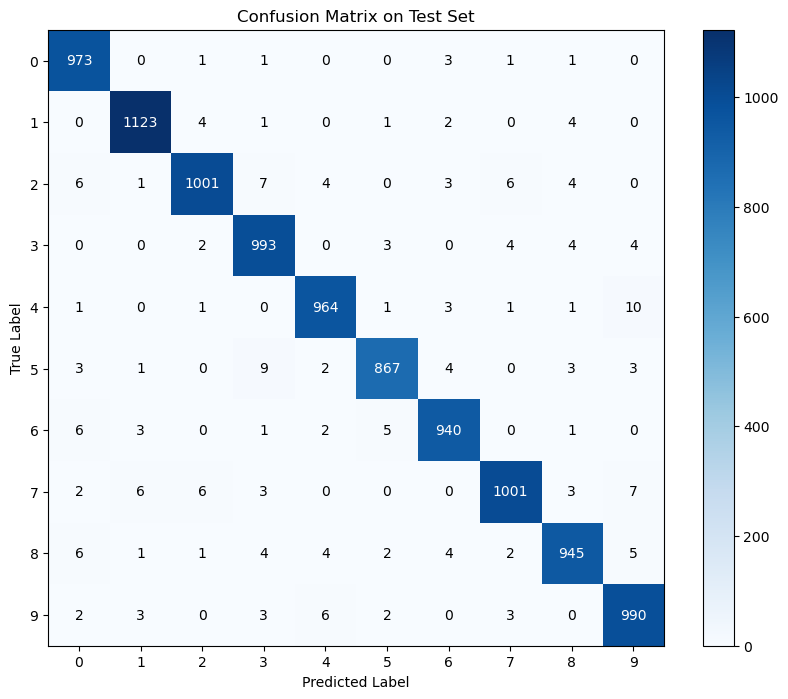

Total misclassifications: 203 out of 10000


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


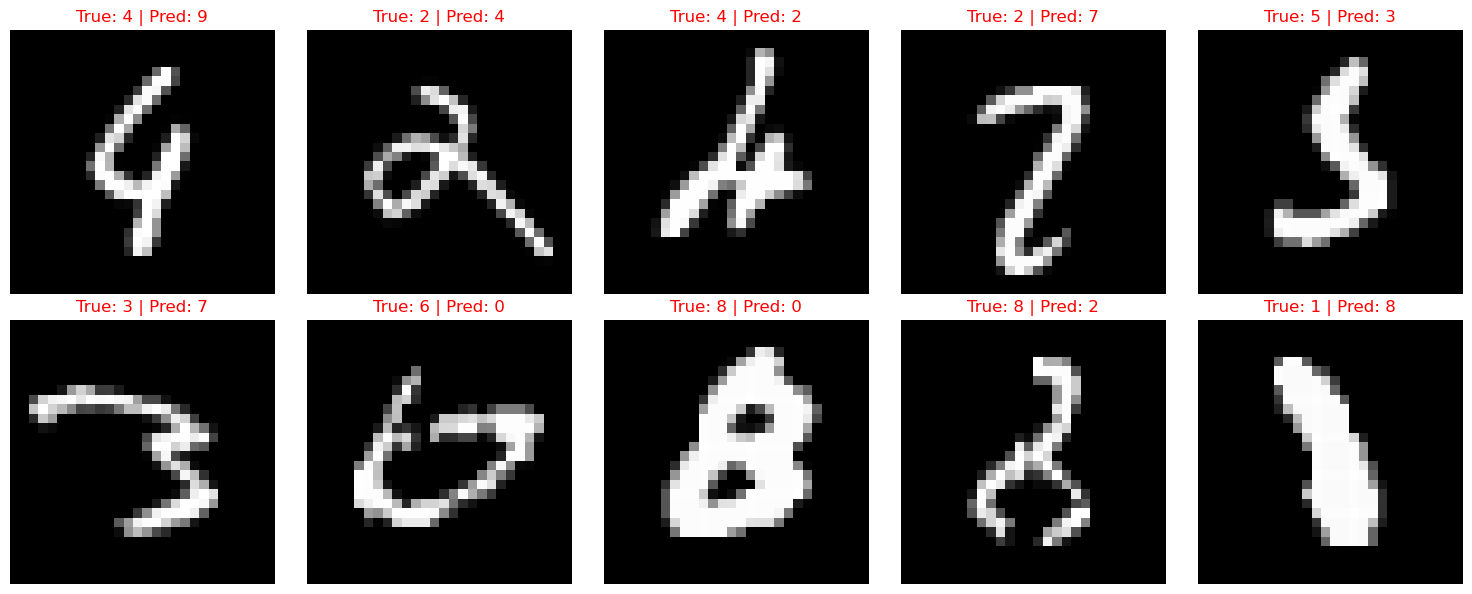

In [15]:
q_2_8_error_analysis()

## 2.10 The Fashion-MNIST Transfer Challenge

In [16]:
def q_2_10_fashion_mnist():
    print("\n" + "="*70)
    print("Question 2.10: Fashion-MNIST Transfer Challenge")
    print("="*70)

    X_train, y_train_oh, X_val, y_val_oh, _, _ = load_and_preprocess_data('fashion_mnist')

    # Placeholder: You will fill these in once your sweep tells you what works on digits!
    configs_to_test = [
        {"name": "config_1_baseline", "layers": 1, "sizes": [128], "opt": "nadam", "act": "relu"},
        {"name": "config_2_very_deep",   "layers": 3, "sizes": [128, 128, 64], "opt": "adam", "act": "relu"},
        {"name": "config_3_deep",    "layers": 2, "sizes": [128, 128], "opt": "nadam", "act": "relu"}
    ]

    for config in configs_to_test:
        print(f"\n--- Testing Fashion-MNIST: {config['name']} ---")
        
        wandb.init(
            project=PROJECT_NAME,
            name=f"2.10_fashion_{config['name']}",
            group="fashion_mnist"
        )

        args = MockArgs()
        args.dataset = 'fashion_mnist'
        args.loss = 'cross_entropy'
        args.learning_rate = 0.0005223702395699795
        args.weight_decay = 0.0001755380601170542
        args.optimizer = config['opt']
        args.activation = config['act']
        args.weight_init = 'xavier'
        args.num_layers = config['layers']
        args.hidden_size = config['sizes']

        model = NeuralNetwork(args)
        model.train(X_train, y_train_oh, X_val, y_val_oh, epochs=15, batch_size=64)

        wandb.finish()

In [17]:
q_2_10_fashion_mnist()


Question 2.10: Fashion-MNIST Transfer Challenge
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Testing Fashion-MNIST: config_1_baseline ---


Epoch-1: Train Loss = 0.4517, Train Accuracy = 0.8531, Val Accuracy = 0.8430
Epoch-2: Train Loss = 0.4031, Train Accuracy = 0.8685, Val Accuracy = 0.8623
Epoch-3: Train Loss = 0.3935, Train Accuracy = 0.8686, Val Accuracy = 0.8577
Epoch-4: Train Loss = 0.3680, Train Accuracy = 0.8783, Val Accuracy = 0.8660
Epoch-5: Train Loss = 0.3400, Train Accuracy = 0.8892, Val Accuracy = 0.8760
Epoch-6: Train Loss = 0.3416, Train Accuracy = 0.8883, Val Accuracy = 0.8705
Epoch-7: Train Loss = 0.3284, Train Accuracy = 0.8930, Val Accuracy = 0.8787
Epoch-8: Train Loss = 0.3156, Train Accuracy = 0.8972, Val Accuracy = 0.8817
Epoch-9: Train Loss = 0.3001, Train Accuracy = 0.9042, Val Accuracy = 0.8873
Epoch-10: Train Loss = 0.3086, Train Accuracy = 0.8999, Val Accuracy = 0.8807
Epoch-11: Train Loss = 0.2941, Train Accuracy = 0.9073, Val Accuracy = 0.8803
Epoch-12: Train Loss = 0.2838, Train Accuracy = 0.9116, Val Accuracy = 0.8882
Epoch-13: Train Loss = 0.3062, Train Accuracy = 0.9015, Val Accuracy = 0.

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-15: Train Loss = 0.2871, Train Accuracy = 0.9093, Val Accuracy = 0.8877


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
layer_0_dead_neurons_pct,▁▂▃▃▄▅▄▆▅▆▇▇▆██
layer_0_grad_norm,▄▃▄█▄▄▂▃▄▁▆▄▄▅▂
train_acc,▁▃▃▄▅▅▆▆▇▆▇█▇█▇
train_loss,█▆▆▅▃▃▃▂▂▂▂▁▂▁▁
val_acc,▁▄▃▄▆▅▆▇█▇▇█▆██
val_loss,█▅▅▄▂▃▂▂▁▂▁▁▃▁▁
epoch,15
layer_0_dead_neurons_pct,44.01042
layer_0_grad_norm,0.7681
train_acc,0.90926


...


--- Testing Fashion-MNIST: config_3_deep ---


Epoch-1: Train Loss = 0.4234, Train Accuracy = 0.8642, Val Accuracy = 0.8588
Epoch-2: Train Loss = 0.3863, Train Accuracy = 0.8755, Val Accuracy = 0.8640
Epoch-3: Train Loss = 0.3551, Train Accuracy = 0.8863, Val Accuracy = 0.8732
Epoch-4: Train Loss = 0.3369, Train Accuracy = 0.8909, Val Accuracy = 0.8762
Epoch-5: Train Loss = 0.3211, Train Accuracy = 0.8963, Val Accuracy = 0.8815
Epoch-6: Train Loss = 0.3184, Train Accuracy = 0.8974, Val Accuracy = 0.8788
Epoch-7: Train Loss = 0.2915, Train Accuracy = 0.9083, Val Accuracy = 0.8887
Epoch-8: Train Loss = 0.2942, Train Accuracy = 0.9073, Val Accuracy = 0.8853
Epoch-9: Train Loss = 0.2904, Train Accuracy = 0.9086, Val Accuracy = 0.8830
Epoch-10: Train Loss = 0.2910, Train Accuracy = 0.9064, Val Accuracy = 0.8807
Epoch-11: Train Loss = 0.2703, Train Accuracy = 0.9148, Val Accuracy = 0.8902
Epoch-12: Train Loss = 0.2659, Train Accuracy = 0.9179, Val Accuracy = 0.8902
Epoch-13: Train Loss = 0.2690, Train Accuracy = 0.9162, Val Accuracy = 0.

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch-15: Train Loss = 0.2458, Train Accuracy = 0.9263, Val Accuracy = 0.8918


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
layer_0_dead_neurons_pct,▁▂▃▄▄▅▅▅▆▆▇█▇██
layer_0_grad_norm,▄▇▁▂▅▂▁▇██▆▆▂▆▁
layer_1_dead_neurons_pct,▁▃▆▅▆▇▄▆▆▆▆▇▇█▇
train_acc,▁▂▃▄▅▅▆▆▆▆▇▇▇▇█
train_loss,█▇▅▅▄▄▃▃▃▃▂▂▂▂▁
val_acc,▁▂▄▅▆▅▇▇▆▆██▆▇█
val_loss,█▆▄▄▃▄▂▃▃▃▂▁▂▄▁
epoch,15
layer_0_dead_neurons_pct,54.24805
layer_0_grad_norm,0.91108
